In [246]:
import archetypes
import duckdb
import pandas as pd
import numpy as np
from pathlib import Path
import diskcache
from itertools import chain
from collections import Counter

import igraph as ig
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

from utils.pandas_setup import pandas_setup
pandas_setup()
# from AA_Abstract import AA_Abstract
# from AA_Original import AA_Original

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [247]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql("ATTACH IF NOT EXISTS ':memory:'")
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        for tab in ['econ.edge_list_sources', 'econ.edge_list_institutions', 'econ.edge_list_both']: 
            self.db.sql(f"DROP TABLE IF EXISTS {tab}")
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname

In [ ]:
import archetypes.datasets


class ArchetypeAnalysis(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def extract_table(self):
        self.data = self.db.sql("SELECT * FROM econ.summary_full").df().sort_values(['works_count_endogenous'], ascending=[False]).reset_index(drop=True)
        self.data['c/h/h'] = self.data.citations_endogenous/(self.data.h_index*self.data.h_index)
        print(f'{self.data.shape = }\n{self.data.head()}\n{self.data.tail()}')
        return
    
    def condition_data(self):
        self.columns = ['works_count_endogenous', 'h_index', 'reputation_sources', 
                        'citedness', 'citations_endogenous', 'hca_endogenous', 'hca_total', 'c/h/h',
                        'gini_citer', 'gini_cited', 'gini_coauthors', 'group', 'author_id', 'author_name']
        mask = [g in ['C', 'T'] or i < 2048 for i, g in zip(self.data.index, self.data['group'])]
        self.df = self.data.loc[mask, self.columns].fillna(0)
        print(f'unfiltered DataFrame {self.df.shape = }\n{self.df.head()}')
        return

    def run_archetype(self):

        X = self.df.drop(columns=['group', 'author_id', 'author_name']).to_numpy().astype(np.float64)
        print(f'INPUT DataFrame {self.df.shape = }\n{self.df.head()}')
        n_archetypes = 5
        self.model =  archetypes.AA(n_archetypes=n_archetypes, random_state=99)
        self.X_trans = self.model.fit(X).transform(X)
        return
    
    def report_archtypes(self):
        print(f'{self.model.n_archetypes = }')
        cols = self.columns
        self.arch = pd.DataFrame(self.model.archetypes_, columns=cols[:-3], index=[f'A_{n}' for n in range(self.model.archetypes_.shape[0])])
        print(f'{self.arch.shape = }\n{self.arch.head(32)}')
        print(f'{self.X_trans.shape = }')
        self.trans = pd.DataFrame(self.X_trans, index=self.df.author_id, columns=self.arch.index)
        self.trans['author_id'] = self.trans.index
        self.trans['author_name'] = self.df.author_name.tolist()
        self.trans['group'] = self.df['group'].tolist()
        self.trans = self.trans.reset_index(drop=True)
        for archetype in self.arch.index:
            print(f'Sorted by archetype {archetype = }') 
            print(f'{self.trans.sort_values(archetype, ascending=False).shape = }\n{self.trans.sort_values(archetype, ascending=False).head(8)}\n{self.trans.sort_values(archetype, ascending=False).tail(8)}')
            self.df[archetype] = self.trans[archetype]
        return

    
    def simplex_plot(self):
        mask = [x in ['C', 'T'] for x in self.df['group']]

        labels = [g if g in ["C", "T"] else '' for g in self.df['group']]
        # mask = [True for x in self.data['group']]
        X_trans_filter = self.X_trans
        point_colour=['blue' if g == 'C' else 'red' if g == 'T' else 'gray' for g in self.df['group']]
        point_size=[40 if g == 'C' else 40 if g == 'T' else 1 for g in self.df['group']]
        fig, ax = plt.subplots(1, 2, figsize=[20, 10])
        archetypes.visualization.simplex(X_trans_filter, show_direction=True, labels=labels, c=point_colour, s=point_size, ax=ax[0])
        sns.heatmap((self.arch-self.arch.mean())/self.arch.std(), ax=ax[1])
        # archetypes.visualization.heatmap(X_trans, ax=ax[1], labels=[arch.index, arch.columns])
        plt.show()
    
    def parallel_plot(self):
        # Calculate the average values for each category
        cols = self.columns
        df = self.df[cols[:-2]] #.set_index(['author_id', 'group'])
        print(df.head())
        df_zscore = (df - df.mean())/df.std()
        df_long = df_zscore #.reset_index()  #.melt(id_vars=['author_id', 'group'], var_name='measure', value_name='value')
        print(df_long.head())

        # Create parallel plot
        plt.figure(figsize=(8, 6))
        g = sns.lineplot(data=df_long.T,            WITH get_work_institution_CTE AS (
                SELECT DISTINCT work_id, institution_id 
                FROM project.authorships
            ),
            institution_counts AS (
                SELECT
                    institution_id,
                    COUNT(work_id) AS works_count
                FROM get_work_institution_CTE
                GROUP BY institution_id
            ),
            ranked_institutions AS (
                SELECT
                    ROW_NUMBER() OVER (ORDER BY works_count DESC) AS row_number,
                    institution_id,
                    works_count
                FROM institution_counts
            )
            CREATE OR REPLACE TABLE memory.institutions AS
            SELECT *
            FROM ranked_institutions
            WHERE works_count >= 150
            ORDER BY works_count DESC
                            dashes=False,
                            markers=True,
                            markersize=8,
                            legend=False,)

        # Add title
        plt.title('Parallel Plot')

        # Remove y-axis ticks and tick labels
        plt.yticks([])
        plt.xticks(rotation='vertical')


        # Display the chart
        plt.show()

In [249]:
def main():

    aa = ArchetypeAnalysis()
    aa.extract_table()
    aa.condition_data()
    aa.run_archetype()
    aa.report_archtypes()
    aa.simplex_plot()
    # aa.parallel_plot()
    
    return

┌──────────┬─────────┬───────────────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

/home/lc/Projects/EconomicsBusiness/.venv/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/home/lc/Projects/EconomicsBusiness/.venv/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


self.model.n_archetypes = 5
self.arch.shape = (5, 11)
     works_count_endogenous    h_index  reputation_sources  citedness  citations_endogenous  hca_endogenous  hca_total     c/h/h  gini_citer  gini_cited  gini_coauthors
A_0              312.318169  71.680157            0.713432   3.798281           3107.383254        3.336777   1.687985  0.604167    0.521561    0.507890        0.445184
A_1               48.000000   7.000000            1.103258   0.000000              2.000000        0.000000   0.000000  0.040816    0.000000    0.000000        0.000000
A_2               70.207406  89.606476            1.644098  10.559687          10362.687166       26.045284  22.403591  2.244814    0.394283    0.322324        0.357719
A_3                3.000000  46.000000            1.391235   3.303571              6.000000        0.000000   0.000000  0.002836    0.019592    0.000000        0.000000
A_4               11.323638  62.860703            1.247708   3.854639             18.805597        0.

/home/lc/Projects/EconomicsBusiness/.venv/lib/python3.12/site-packages/archetypes/visualization/simplex.py:146: RuntimeWarning: invalid value encountered in divide
  projections /= np.linalg.norm(projections, axis=1)[:, None]


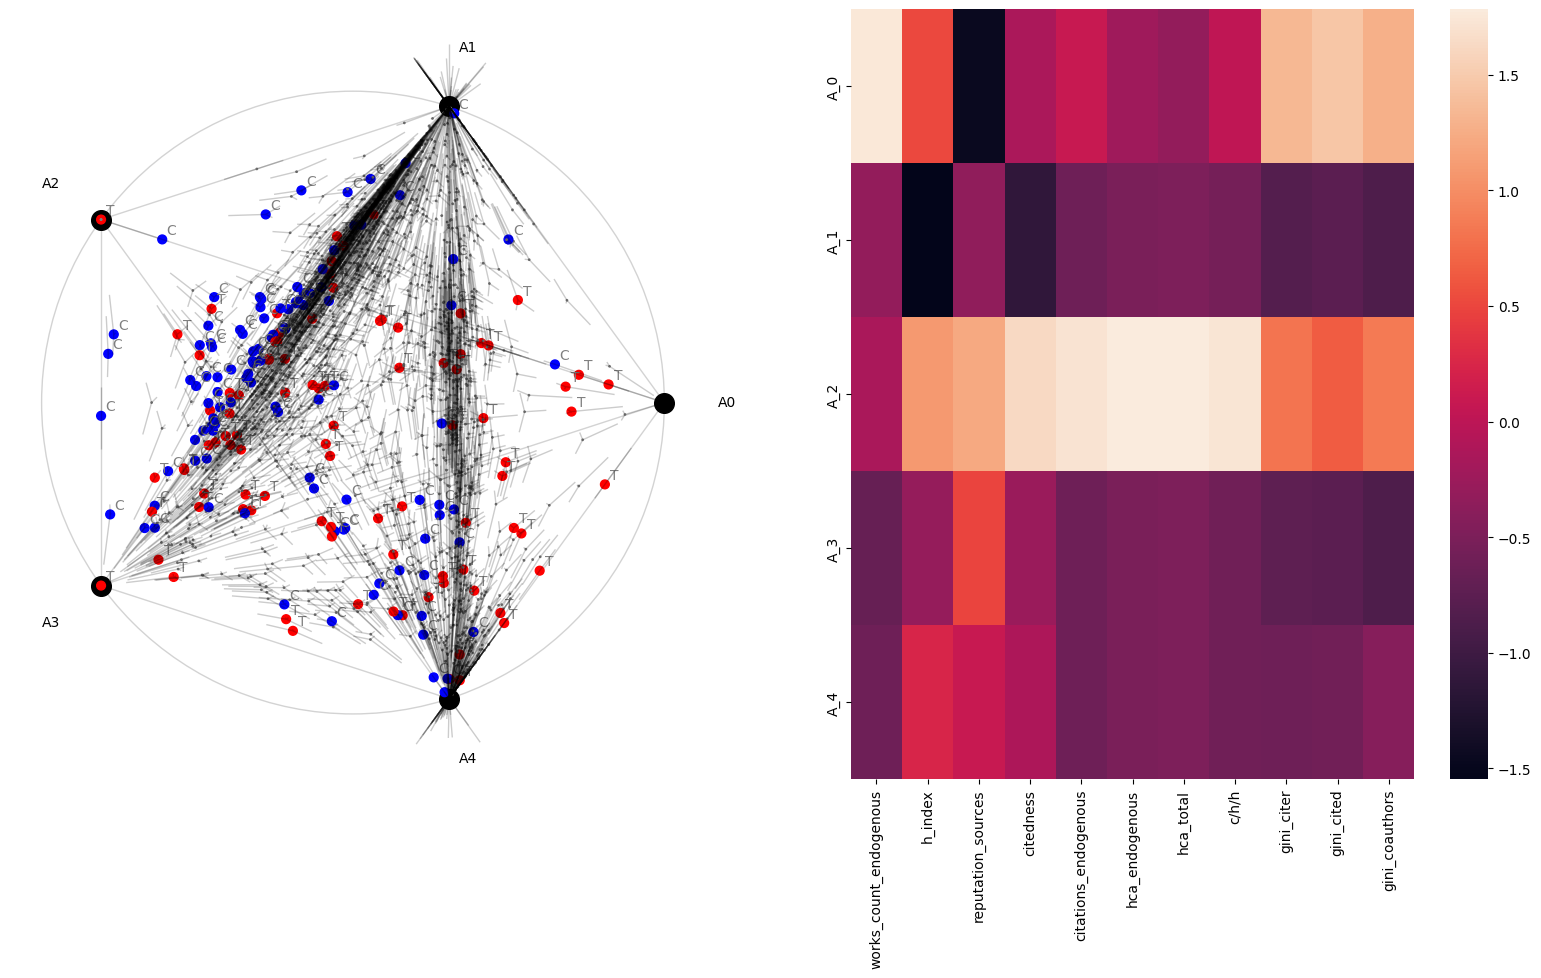

DONE!


In [250]:
if __name__ == "__main__":
    main()
    print("DONE!")